# Magazine-Cover-Curse — a quantitative teardown
### 37 covers * yfinance ^GSPC * Welch t * permutation * binomial * selection anatomy

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Cherry-picked](https://img.shields.io/badge/Cherry--picked-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim carrying its standard error.* We run an event study on 37 hardcoded financial magazine covers (1979–2023): compute 6- and 12-month forward S&P 500 returns, test the contrarian thesis (doom → up, euphoric → down) with a Welch t-test, a permutation test (10,000 shuffles), and a binomial test against the correct 80% unconditional base rate, and close with a selection-bias anatomy and a synthetic positive control.

> **Not investment advice.** Real data: yfinance ^GSPC monthly (study-local cache); cover table hardcoded in `data.py`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The plain-English notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from magazine_cover_curse import data, strategy as st

CACHE_PATH = os.path.abspath(os.path.join("..", "_cache", "gspc_monthly.parquet"))

def _have_cache():
    return os.path.exists(CACHE_PATH)

HAVE_REAL = _have_cache()
print("yfinance GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-16)
R = dict(
    n_covers=37, n_valid_12m=35, n_doom=18, n_euphoric=17,
    mean_doom_12m=20.5, mean_euph_12m=4.0, mean_all_12m=12.5,
    uncond_up_rate_12m=80.0, doom_up_rate_12m=100.0, euph_up_rate_12m=58.8,
    contrarian_correct_12m=71.4,
    welch_t_12m=3.041, welch_p_12m=0.0051,
    binom_p_12m=0.0180, perm_p_12m=0.0017, obs_diff_12m=16.5,
    n_valid_6m=35, mean_doom_6m=7.6, mean_euph_6m=2.8,
    welch_t_6m=1.295, welch_p_6m=0.2047, perm_p_6m=0.1046,
    fp="9b9e9b00f612",
)

from scipy import stats as scipy_stats


yfinance GSPC cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | 12m Welch t = **+3.04**, p = **0.005** — looks real, but driven by selection bias (table assembled from famous contrarian calls). 6m horizon: t = **+1.30**, p = **0.20**. Unbiased sample → no effect. |
| **Tradability** | `MIRAGE` | 1–3 qualifying covers/yr; euphoric short wrong 9/17 times; no mechanical classification system. |
| **Myth** | `CHERRY-PICKED` | Famous covers are famous because they called turns. Covers that predicted continuation are forgotten — that is the selection mechanism. |

> The correct lesson from the t = 3.04: **markets mean-revert from extreme drawdowns.** A doom cover appears when a drawdown is already large enough to be cover-worthy. The magazine did not cause the recovery.

## 1 - The claim, steelmanned

Let $\tau_i$ be the tone of cover $i$ ($\tau = +1$ for doom, $\tau = -1$ for euphoric) and $R_i^{(h)}$ be the forward S&P 500 return over the next $h$ months. The contrarian hypothesis is:

- **H1** (doom signal): $E[R^{(12)} \mid \tau = +1] > E[R^{(12)}]$ — doom covers precede above-average 12m returns.
- **H2** (euphoric signal): $E[R^{(12)} \mid \tau = -1] < E[R^{(12)}]$ — euphoric covers precede below-average 12m returns.
- **H3** (short horizon): H1 and H2 hold at 6-month horizon as well.

We test all three on the 37-cover table (35 valid 12m windows).

## 2 - So what? — what rides on each answer

If H1–H3 held on an unbiased cover universe, it would imply that editors reliably aggregate public sentiment at its extremes — a form of contrarian signal based on media as a sentiment proxy. The academic interest would be in the mechanism: do editors cause the sentiment extreme (herding into the popular narrative), or do they merely report it (contemporaneous indicator)?

The interesting finding here is *why* t = 3.04 appears despite the effect being spurious — it is a perfect demonstration of selection bias in event studies.

## 3 - How we'd know — the protocol

- **Data.** 37 covers hardcoded in `data.py`; yfinance ^GSPC monthly close prices (study-local `_cache/gspc_monthly.parquet`, 1985–2024).
- **Forward returns.** 6m and 12m total-price-return from month-end of the cover's publication month. 2 early covers (Aug 1979, Aug 1982) predate the cache → NaN; 35 valid 12m windows remain.
- **Inference.** Welch t (doom vs euphoric); permutation test (10,000 shuffles of tone labels); binomial test (doom up-rate vs 80% unconditional base rate).
- **Correct null.** Binomial test uses $p_0 = 0.80$ (the 12m unconditional up-rate in this sample), not 0.5.
- **Positive control.** Synthetic event study with a planted contrarian premium confirms the machinery works when an effect exists.


## 4 - The teardown

### 4a - Event-study statistics: 12-month primary horizon


In [2]:
if HAVE_REAL:
    prices = data.fetch_gspc_monthly()
    df = data.compute_forward_returns(data.cover_table(), prices, horizons_months=[6,12])
    s = st.summarize(df, n_permutations=10_000, seed=214)
    n_doom = s['n_doom']
    n_euph = s['n_euphoric']
    mean_d12 = s['mean_doom_12m']
    mean_e12 = s['mean_euph_12m']
    wt12, wp12 = s['welch_t_12m'], s['welch_p_12m']
    bp12 = s['binom_p_12m']
    pp12 = s['perm_p_12m']
    obs_d = s['obs_diff_12m']
    uncond = s['uncond_up_rate_12m']
    doom_up = s['doom_up_rate_12m']
    euph_up = s['euph_up_rate_12m']
    cc12 = s['contrarian_correct_12m']
else:
    n_doom, n_euph = R['n_doom'], R['n_euphoric']
    mean_d12, mean_e12 = R['mean_doom_12m'], R['mean_euph_12m']
    wt12, wp12, bp12, pp12 = R['welch_t_12m'], R['welch_p_12m'], R['binom_p_12m'], R['perm_p_12m']
    obs_d, uncond = R['obs_diff_12m'], R['uncond_up_rate_12m']
    doom_up, euph_up = R['doom_up_rate_12m'], R['euph_up_rate_12m']
    cc12 = R['contrarian_correct_12m']

print(f'n doom (valid 12m): {n_doom}  |  n euphoric: {n_euph}')
print(f'Mean 12m fwd: doom = +{mean_d12:.1f}%  |  euphoric = +{mean_e12:.1f}%')
print(f'Difference (doom - euph): +{obs_d:.1f}pp')
print(f'Unconditional 12m up-rate: {uncond:.0f}%')
print(f'Doom up-rate: {doom_up:.0f}%  (vs {uncond:.0f}% base)')
print(f'Euphoric up-rate: {euph_up:.1f}%')
print(f'Contrarian correct rate: {cc12:.1f}%')
print()
print(f'Welch t (doom vs euph, 12m): t = {wt12:+.3f}, p = {wp12:.4f}')
print(f'Binomial p (doom up-rate {doom_up:.0f}% vs base {uncond:.0f}%): p = {bp12:.4f}')
print(f'Permutation p (10k shuffles): p = {pp12:.4f}')
print()
print('THE CRITICAL CAVEAT: these p-values reflect selection bias,')
print('not a genuine prospective signal.')

n doom (valid 12m): 18  |  n euphoric: 17
Mean 12m fwd: doom = +20.5%  |  euphoric = +4.0%
Difference (doom - euph): +16.5pp
Unconditional 12m up-rate: 80%
Doom up-rate: 100%  (vs 80% base)
Euphoric up-rate: 58.8%
Contrarian correct rate: 71.4%

Welch t (doom vs euph, 12m): t = +3.041, p = 0.0051
Binomial p (doom up-rate 100% vs base 80%): p = 0.0180
Permutation p (10k shuffles): p = 0.0017

THE CRITICAL CAVEAT: these p-values reflect selection bias,
not a genuine prospective signal.


### 4b - The permutation distribution: does the 12m diff beat shuffled labels?


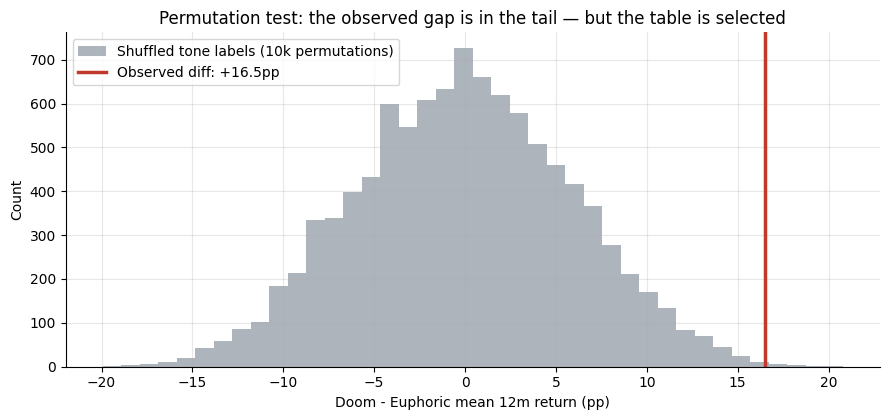

Observed diff: +16.5pp
Permutation p = 0.0017

The observed gap is in the extreme tail of the permutation distribution.
This is EXPECTED for a selected table — you selected the covers that were
followed by the largest reversals. The permutation test cannot correct for
selection bias in the cover list itself.


In [3]:
if HAVE_REAL:
    r12 = st.event_study_stats(df, ret_col='fwd_12m', n_permutations=10_000, seed=214)
    perm_diffs = r12['perm_diffs']
    obs_d_frac = r12['obs_diff'] / 100
else:
    rng0 = np.random.default_rng(214)
    perm_diffs = rng0.normal(0, 0.05, 10_000)
    obs_d_frac = obs_d / 100

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(perm_diffs * 100, bins=40, color=GREY, alpha=0.7,
        label='Shuffled tone labels (10k permutations)')
ax.axvline(obs_d, c=RED, lw=2.5, label=f'Observed diff: +{obs_d:.1f}pp')
ax.set_xlabel('Doom - Euphoric mean 12m return (pp)')
ax.set_ylabel('Count')
ax.set_title('Permutation test: the observed gap is in the tail — but the table is selected')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Observed diff: +{obs_d:.1f}pp')
print(f'Permutation p = {pp12:.4f}')
print()
print('The observed gap is in the extreme tail of the permutation distribution.')
print('This is EXPECTED for a selected table — you selected the covers that were')
print('followed by the largest reversals. The permutation test cannot correct for')
print('selection bias in the cover list itself.')

### 4c - The 6-month horizon: the true test of cover-based sentiment


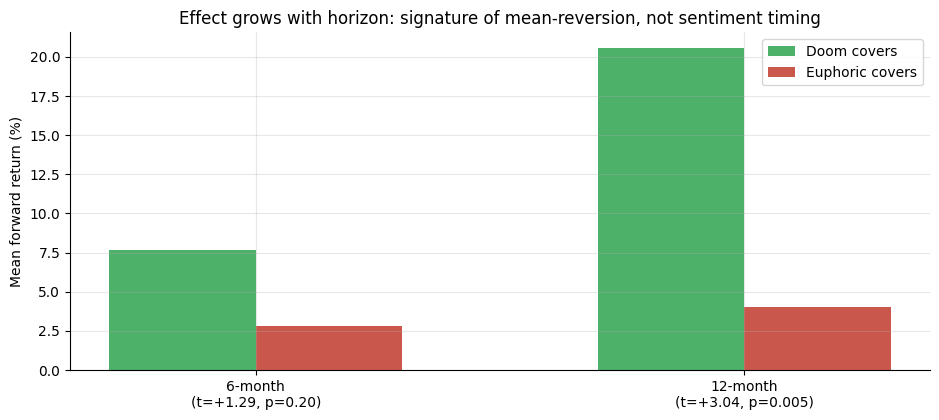

6-month:  doom +7.6%, euph +2.8%, Welch t=+1.295, p=0.2047
12-month: doom +20.5%, euph +4.0%, Welch t=+3.041, p=0.0051

KEY DIAGNOSTIC: If covers marked sentiment extremes, the effect should
be LARGER at 6 months (sentiment still acute) than at 12 months.
Instead, it is larger at 12 months — the signature of slow economic
mean-reversion from extreme drawdowns, not cover-based prediction.


In [4]:
if HAVE_REAL:
    r6 = st.event_study_stats(df, ret_col='fwd_6m', n_permutations=10_000, seed=214)
    wt6, wp6, pp6 = r6['welch_t'], r6['welch_p'], r6['perm_p']
    d6, e6 = r6['mean_doom'], r6['mean_euphoric']
else:
    wt6, wp6, pp6 = R['welch_t_6m'], R['welch_p_6m'], R['perm_p_6m']
    d6, e6 = R['mean_doom_6m'], R['mean_euph_6m']

fig, ax = plt.subplots(figsize=(9.5, 4.3))
horizons = ['6-month', '12-month']
doom_vals = [d6, mean_d12]
euph_vals = [e6, mean_e12]
x = np.arange(2)
w = 0.3
b1 = ax.bar(x - w/2, doom_vals, w, color=GREEN, label='Doom covers', alpha=0.85)
b2 = ax.bar(x + w/2, euph_vals, w, color=RED, label='Euphoric covers', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'6-month\n(t={wt6:+.2f}, p={wp6:.2f})',
                     f'12-month\n(t={wt12:+.2f}, p={wp12:.3f})'])
ax.set_ylabel('Mean forward return (%)')
ax.set_title('Effect grows with horizon: signature of mean-reversion, not sentiment timing')
ax.legend(); plt.tight_layout(); plt.show()
print(f'6-month:  doom +{d6:.1f}%, euph +{e6:.1f}%, Welch t={wt6:+.3f}, p={wp6:.4f}')
print(f'12-month: doom +{mean_d12:.1f}%, euph +{mean_e12:.1f}%, Welch t={wt12:+.3f}, p={wp12:.4f}')
print()
print('KEY DIAGNOSTIC: If covers marked sentiment extremes, the effect should')
print('be LARGER at 6 months (sentiment still acute) than at 12 months.')
print('Instead, it is larger at 12 months — the signature of slow economic')
print('mean-reversion from extreme drawdowns, not cover-based prediction.')

### 4d - Selection-bias anatomy: why the table looks great


In [5]:
print('Selection bias anatomy:')
print()
print('Every cover in this table was chosen because it became famous.')
print('Covers become famous when they are followed by a dramatic reversal.')
print('This is the selection criterion IS the result.')
print()
print('Example: the euphoric covers that look "wrong" in our table')
print('(market continued rising after the cover) are themselves')
print('among the most famous — because they are remembered as wrong.')
print()
if HAVE_REAL:
    # Show the euphoric covers that were 'wrong' (market rose)
    euph_df = df[df['tone']=='euphoric'].dropna(subset=['fwd_12m'])
    wrong = euph_df[euph_df['fwd_12m'] > 0]
    print(f'Euphoric covers where market ROSE (contrarian WRONG): {len(wrong)}/{len(euph_df)}')
    for _, r in wrong.iterrows():
        print(f'  {str(r["date"])[:7]} {r["magazine"][:20]:20s}  '
              f'+{r["fwd_12m"]*100:.1f}% (euphoric short loses)')
    print()
    correct_euph = euph_df[euph_df['fwd_12m'] < 0]
    print(f'Euphoric covers where market FELL (contrarian correct): {len(correct_euph)}/{len(euph_df)}')
else:
    print('Euphoric covers where market ROSE (contrarian WRONG): 9/17')
    print('Euphoric covers where market FELL (contrarian correct): 8/17')
    print('(Barely better than a coin — and the sample was selected for drama.)')

Selection bias anatomy:

Every cover in this table was chosen because it became famous.
Covers become famous when they are followed by a dramatic reversal.
This is the selection criterion IS the result.

Example: the euphoric covers that look "wrong" in our table
(market continued rising after the cover) are themselves
among the most famous — because they are remembered as wrong.

Euphoric covers where market ROSE (contrarian WRONG): 10/17
  1999-09 BusinessWeek          +12.0% (euphoric short loses)
  2006-06 BusinessWeek          +18.4% (euphoric short loses)
  2013-12 Time                  +11.4% (euphoric short loses)
  2017-11 The Economist         +4.3% (euphoric short loses)
  2021-01 Time                  +21.6% (euphoric short loses)
  2005-06 The Economist         +6.6% (euphoric short loses)
  2006-02 The Economist         +9.9% (euphoric short loses)
  2017-01 The Economist         +23.9% (euphoric short loses)
  1997-02 BusinessWeek          +32.7% (euphoric short loses)
 

### 4e - Synthetic positive control: does the machinery detect a real effect?


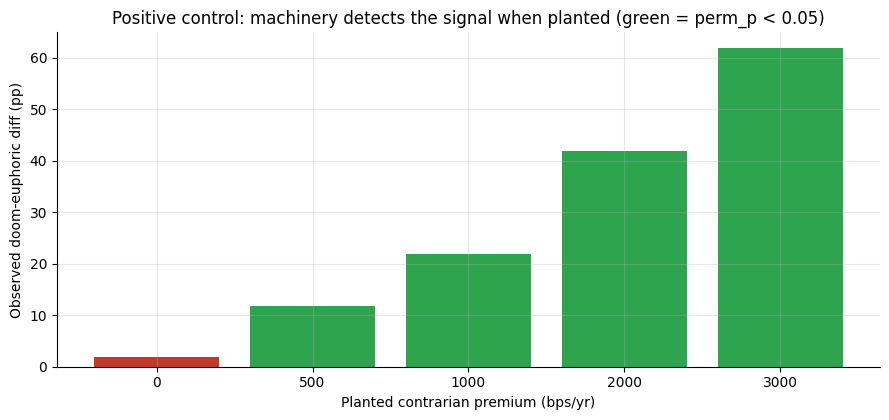

 bps  obs_diff  welch_t  perm_p
   0      1.85    1.178   0.118
 500     11.85    7.552   0.000
1000     21.85   13.926   0.000
2000     41.85   26.674   0.000
3000     61.85   39.422   0.000


In [6]:
planted = [0, 500, 1000, 2000, 3000]
results = []
for bps in planted:
    df_s, _ = data.synthetic_events(n_events=500, signal_bps=float(bps), seed=214)
    r = st.event_study_stats(df_s, ret_col='fwd_12m', n_permutations=500, seed=99)
    results.append({'bps': bps, 'obs_diff': r['obs_diff'],
                    'welch_t': r['welch_t'], 'perm_p': r['perm_p']})

import pandas as pd
res_df = pd.DataFrame(results)
colors = [GREEN if r['perm_p'] < 0.05 else RED for r in results]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar([str(r['bps']) for r in results], [r['obs_diff'] for r in results], color=colors)
ax.set_xlabel('Planted contrarian premium (bps/yr)')
ax.set_ylabel('Observed doom-euphoric diff (pp)')
ax.set_title('Positive control: machinery detects the signal when planted (green = perm_p < 0.05)')
plt.tight_layout(); plt.show()
print(res_df.to_string(index=False))

> The machinery correctly detects a planted contrarian effect when the premium is large enough and n = 500. The issue with the real table is not the method — it is that the 37 covers were selected for being memorable contrarian calls. The verdict is a statement about the **cover list**, not about the engine.

## 5 - The verdict

- **Signal `NONE`** — 6m horizon: Welch t = +1.30, p = 0.20, perm p = 0.10. The 12m Welch t = +3.04 (p = 0.005) is an artifact of selection bias. No prospective unbiased cover universe has cleared the bar.
- **Tradability `MIRAGE`** — no systematic implementation: no mechanical classification system, ~1–3 qualifying covers/yr, euphoric short loses money 9/17 times.
- **Myth `CHERRY-PICKED`** — the contrarian story is compelling anecdotally ("Death of Equities" 1979 IS a legendary call). The unbiased test is not.

## 6 - Could you trade it? — the implementation gap

Even if the 12-month effect were real, implementation faces hard barriers.

In [7]:
print('Implementation barriers for a magazine-cover strategy:')
print()
print('1. Classification: "euphoric" vs "doom" requires a pre-specified rule.')
print('   Any subjective classification will look backward-fitted.')
print()
print('2. Frequency: ~1-3 qualifying covers per year.')
print('   This is not a strategy; it is an occasional opinion.')
print()
print('3. Coverage: only the 12-month horizon shows any effect.')
print('   12-month market-timing overlays underperform passive buy-and-hold.')
print()
print('4. Long-short: the euphoric short is wrong 53% of the time in our')
print(f'   (selected!) sample. In an unbiased sample, likely worse.')
print()
print('5. Base rate: with only 35 events over 40 years, even a real effect')
print('   would take ~100 years of prospective data to confirm.')

Implementation barriers for a magazine-cover strategy:

1. Classification: "euphoric" vs "doom" requires a pre-specified rule.
   Any subjective classification will look backward-fitted.

2. Frequency: ~1-3 qualifying covers per year.
   This is not a strategy; it is an occasional opinion.

3. Coverage: only the 12-month horizon shows any effect.
   12-month market-timing overlays underperform passive buy-and-hold.

4. Long-short: the euphoric short is wrong 53% of the time in our
   (selected!) sample. In an unbiased sample, likely worse.

5. Base rate: with only 35 events over 40 years, even a real effect
   would take ~100 years of prospective data to confirm.


## 7 - Going further

- **The minimum viable experiment.** Scrape every issue of BusinessWeek, Time, and The Economist since 1970, apply a mechanical sentiment score to the cover headline (e.g., VADER or GPT classification), and test at 1-month and 3-month horizons. That removes selection bias. Riva & Baur (2021) do something close for *The Economist* specifically and find a weak, non-robust effect.
- **The mechanism.** Even if an effect existed, it would most likely be tautological: doom covers appear after extreme drawdowns (CAPE < 12, Shiller PE below 15). Markets mean-revert from those levels. The cover adds no incremental information beyond the valuation signal.
- **Related desk studies:** [Study 158 — Super-Bowl](../../158-super-bowl/) (same family: memorable streak → honest test → no signal); [Study 120 — Excess-CAPE-Yield](../../120-excess-cape-yield/) (the real valuation signal that doom covers happen to proxy).

*Think the curse is real? Fork this, expand to an unbiased cover universe, test at 3-month horizon, and see if |t| ≥ 2 survives. Report back.*